# Project 3 Assignment

## Assignment Overview & Instructions

The objective of project 3 is to perform keyword network analysis and word frequency
analysis.  
Please complete the following 7 tasks in this assessment, using the instructions indicated below.   

**Note:** You may create your own custom functions if necessary to complete the tasks.

### Task 1: Import the Dataset for use in your Notebook.   

You can find the source dataset [here](https://drive.google.com/file/d/1YJe45YXo0xSkFClGPBhKYLzupFEyGadK/view?usp=sharing)

In [ ]:
## YOUR CODE HERE
# Import the libraries needed for this project
import pandas as pd
import itertools
import networkx as nx
import matplotlib.pyplot as plt

#declare filepath
file_path = "data/keywords_data.csv"

#converting csv file into a dataframe
df = pd.read_csv(file_path)

# Display the first 5 rows so we can confirm the file loaded correctly
df.head()

,Title,Keyword 1,Keyword 2,Keyword 3,Keyword 4,Keyword 5,Keyword 6,Keyword 7,Keyword 8,Keyword 9,Keyword 10,Keyword 11,Keyword 12
0,Feb/03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Meta-Analyses of Financial Performance and Equ...,EQUITY,ORGANIZATIONAL sociology,PERFORMANCE,META-analysis,PSYCHOMETRICS,ORGANIZATIONAL research,FINANCIAL performance,AGENCY theory,ORGANIZATIONAL effectiveness,ORGANIZATIONAL behavior,CORPORATE governance,NaN
3,"Home Country Environments, Corporate Diversifi...",DIVERSIFICATION in industry,BUSINESS planning,PERFORMANCE standards,EMPLOYEES -- Rating of,CORPORATE culture,STRATEGIC planning,ORGANIZATIONAL effectiveness,MANAGEMENT science,MANAGEMENT research,PRODUCT management,NaN,NaN
4,Safeguarding Investments in Asymmetric Interor...,INTERORGANIZATIONAL relations,INTERGROUP relations,BUSINESS communication,INVESTMENTS,SUPPLY chains,KNOWLEDGE management,INTERORGANIZATIONAL networks,CORPORATE governance,GROUP decision making,INTELLECTUAL capital,NaN,NaN


### **Task 2:**  Write a Python code to extract keyword data from the above file.
Write a Python code to extract keyword data from the above file and convert it to a weighted adjacency matrix. See the figure below to understand the process

![Task Two - Adjacency matrix](Task%202%20-%20Figure%201.png)

In [ ]:
## YOUR CODE HERE

# Get only the keyword columns from the dataset
# We do not need the Title column for this task
keyword_columns = [col for col in df.columns if col.lower().startswith("keyword")]

#create a new datadrame that contains only keyword columns
keywords_df = df[keyword_columns].copy()

# Remove rows where all keyword values are missing
# These rows do not represent usable keyword data for network analysis
keywords_df = keywords_df.dropna(how="all").copy()

#convert every keyword to lowercase
for col in keyword_columns:
  keywords_df[col] = keywords_df[col].apply(
      lambda x: x.strip().lower() if isinstance(x,str) else x
  )

#build a sorted list of all unique keywords in the dataset we loop through every row and every keyword in that row
all_keywords = sorted({
    keyword
    for row in keywords_df.itertuples(index=False)
    for keyword in row
    if pd.notna(keyword) and keyword != ""

})


# creating an empty weighted adjacency matrix filled with zeroes
# Rows = unique keywords
# Columns = unique keywords
# Cell values = number of times two keywords co-occur in the same article
adjacency_matrix = pd.DataFrame(
    0,
    index=all_keywords,
    columns=all_keywords,
    dtype = int
)

# Fill the adjacency matrix with co-occurrence counts
# For each article:
#   1. Collect all valid keywords
#   2. Remove duplicate keywords within the same article
#   3. Generate all unique keyword pairs
#   4. Increment both [a, b] and [b, a] to keep the matrix symmetric
for _, row in keywords_df.iterrows():
   # extract valid keywords from the article
    article_keywords = [
        keyword for keyword in row.tolist()
        if pd.notna(keyword) and keyword != ""
    ]

    # remove duplicates while keeping the order intact
    article_keywords = list(dict.fromkeys(article_keywords))

     # Generate all keyword pairs and update the matrix
    for i in range(len(article_keywords)):
        for j in range(i+1, len(article_keywords)):
            keyword_1 = article_keywords[i]
            keyword_2 = article_keywords[j]

            # Increment both directions so the matrix is symmetric
            adjacency_matrix.loc[keyword_1, keyword_2] += 1
            adjacency_matrix.loc[keyword_2, keyword_1] += 1


#show the size of adjacency matrix
print("Adjacency matrix shape:", adjacency_matrix.shape)

#display a small sample of the matrix
adjacency_matrix.iloc[:10, :10]

Adjacency matrix shape: (248, 248)


,agency theory,aggression (psychology),ambivalence,anger in the workplace,behavioral research,boards of directors,break-even analysis,burnout (psychology),business communication,business enterprises
agency theory,0,0,0,0,0,1,0,0,0,0
aggression (psychology),0,0,0,1,0,0,0,0,0,0
ambivalence,0,0,0,0,0,0,0,0,0,0
anger in the workplace,0,1,0,0,0,0,0,0,0,0
behavioral research,0,0,0,0,0,0,0,0,0,0
boards of directors,1,0,0,0,0,0,0,0,0,0
break-even analysis,0,0,0,0,0,0,0,0,0,0
burnout (psychology),0,0,0,0,0,0,0,0,0,0
business communication,0,0,0,0,0,0,0,0,0,0
business enterprises,0,0,0,0,0,0,0,0,0,0


### **Task 3:**  Read the adjacency matrix and convert it into a weighted network

In [ ]:
## YOUR CODE HERE

# create a networkX graph from the adjacency matrix each keyword becomes a node
# each co-occurrence relationship becomes an edge with a weight
graph = nx.from_pandas_adjacency(adjacency_matrix)

#remove any edges with weight 0
zero_weight_edges = [
    (u,v) for u, v, d in graph.edges(data=True)
    if d["weight"] == 0
]
graph.remove_edges_from(zero_weight_edges)

# Remove isolated nodes (nodes with no edges)
# These are keywords that do not connect to any other keyword
isolated_nodes = list(nx.isolates(graph))
graph.remove_nodes_from(isolated_nodes)


# Print the number of nodes and edges in the final weighted network
print("Number of nodes:", graph.number_of_nodes())
print("Number of edges:", graph.number_of_edges())

Number of nodes: 248
Number of edges: 2141


### **Task 4:**  Compute node degree and strength

In [ ]:
## YOUR CODE HERE
# the degree of a node is the number of unique nodes it is connected to
degree_dict = dict(graph.degree())

# the strength of a node is the sum of the weights of all edges of all edges connected to
strength_dict = dict(graph.degree(weight="weight"))

# store both metrics in a DataFrame for easier analysis
node_metrics = pd.DataFrame({
    "keyword": list(graph.nodes()),
    "degree": [degree_dict[node] for node in graph.nodes()],
    "strength": [strength_dict[node] for node in graph.nodes()]
})

# Sort alphabetically for a cleaner display
node_metrics = node_metrics.sort_values("keyword").reset_index(drop=True)

# Display the first few rows of the metrics table
print("Node metrics table:")
node_metrics.head(10)

Node metrics table:


,keyword,degree,strength
0,agency theory,38,48
1,aggression (psychology),18,20
2,ambivalence,9,9
3,anger in the workplace,11,11
4,behavioral research,9,9
5,boards of directors,21,21
6,break-even analysis,11,11
7,burnout (psychology),11,11
8,business communication,9,9
9,business enterprises,9,9


### **Task 5:**  Show the top 10 nodes by degree and top 10 nodes by strength

In [ ]:
## YOUR CODE HERE
# sort the node metrics DataFrame by degree in decending order
# if two keywords have the same degree sort alphabetically by keyword
top_10_degree = (
    node_metrics.sort_values(by=["degree", "keyword"], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)

# sort the node metrics Dataframe by strength in descending order
# if two keywords have the same strength, sort alphabetically by keyword
top_10_strength = (
    node_metrics.sort_values(by=["strength", "keyword"], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)

# Display the top 10 keywords by degree
print("Top 10 nodes by degree:")
display(top_10_degree)

# Display the top 10 keywords by strength
print("Top 10 nodes by strength")
display(top_10_strength)

Top 10 nodes by degree:


,keyword,degree,strength
0,organizational behavior,166,265
1,organizational effectiveness,104,144
2,management science,102,136
3,personnel management,93,126
4,decision making,90,112
5,organizational structure,74,107
6,organizational sociology,66,96
7,strategic planning,66,80
8,industrial management,64,84
9,corporate governance,62,85


Top 10 nodes by strength


,keyword,degree,strength
0,organizational behavior,166,265
1,organizational effectiveness,104,144
2,management science,102,136
3,personnel management,93,126
4,decision making,90,112
5,organizational structure,74,107
6,organizational sociology,66,96
7,corporate governance,62,85
8,industrial management,64,84
9,strategic planning,66,80


### **Task 6:** Show the top 10 node pairs by weight

In [ ]:
## YOUR CODE HERE
# create a list to store each edge and its weight
edge_list = []

#loop through all edges in the graph
for node_1, node_2, data in graph.edges(data=True):
  edge_list.append({
      "keyword_1": node_1,
      "keyword_2": node_2,
      "weight": data["weight"]
  })

# convert the edge list into a DataFrame
edges_df = pd.DataFrame(edge_list)

#sort by weight in descending order
#if weights are tied, sort alphabetically by keyword names
top_10_pairs = (
    edges_df.sort_values(
        by=["weight", "keyword_1", "keyword_2"],
        ascending=[False, True, True]
    )
    .head(10)
    .reset_index(drop=True)
)

#display the top 10 node pairs by edge weight
print("Top 10 node pairs by weight:")
display(top_10_pairs)

Top 10 node pairs by weight:


,keyword_1,keyword_2,weight
0,organizational behavior,organizational effectiveness,11
1,organizational behavior,organizational structure,9
2,organizational behavior,personnel management,8
3,management science,organizational behavior,7
4,corporate governance,organizational behavior,6
5,decision making,organizational behavior,6
6,organizational behavior,organizational sociology,6
7,organizational effectiveness,organizational structure,6
8,industrial management,organizational behavior,5
9,industrial relations,organizational behavior,5


### **Task 7:** Plot strength on y-axis and degree on x-axis

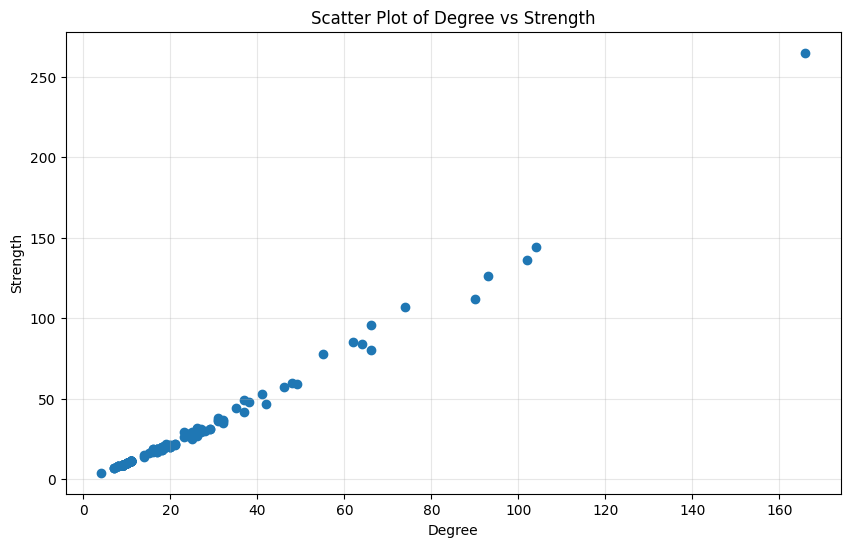

In [ ]:
## YOUR CODE HERE
#create a figure with a readable size
plt.figure(figsize=(10,6))

#create the scatter plot
#x axis- degree
#y axis- strength
plt.scatter(node_metrics["degree"], node_metrics["strength"])

# add axis labels and title
plt.xlabel("Degree")
plt.ylabel("Strength")
plt.title("Scatter Plot of Degree vs Strength")

# adding grid
plt.grid(True, alpha=0.3)

#show plot
plt.show()

## Submitting your Project

Once you've completed your project, it's time to submit your work for grading.   
This week, you will submit your code file `Project 3.ipynb` to the following Staff Graded Assignment for review.  

In order to submit your work, please follow the steps below:
1. Verify you've saved your work using the `Save` button within the Jupyter Notebook
2. Download this notebook using the `File` -> `Download As` -> Choose the `Notebook (.ipynb)` format.
3. Access the following Step 2: Submit Project 3 item.
4. Complete all prompted fields, and upload your Jupyter Notebook file (Project 3.ipynb) in the indicated field.
5. Submit your notebook to "Step 2: Submit Project 3" by the deadline indicated within your course view for the Project 3 Assignment item.

Congratulations on completing the Project 3 Assignment!